In [16]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_auc_score, brier_score_loss

from analysis.loaders import (
    load_activations, load_layer_outputs, load_combined_judgements,
    load_extraction, load_ground_truth, load_trained_probe, load_trained_ntp_calibrator,
    cached_match, load_synthetic_activations, load_synthetic_layer_outputs,
    load_synthetic_responses,
)
from scholarlm.utils.calibration import reliability_diagram_data, rescale_probabilities_em
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "legend.title_fontsize": 11,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

FIGURES_DIR = REPO_ROOT / "figures/calibration/"
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

RESULTS_DIR = REPO_ROOT / "results/"
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# blue: 7, orange: 1, red: 0, green: 4
palette = sns.color_palette("husl", 10)

_DS_COLORS = {
    ('pond', 'syn'):  palette[7],
    ('pond', 'real'): palette[1],
    ('nfix', 'syn'):  palette[4],
    ('nfix', 'real'): palette[0],
}

### Set Parameters

In [7]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASETS = ['pond', 'nfix']
EXTRACTION_MODEL = 'gemma-3-27b'
JUDGE_MODELS = ['llama-3.1-8b']
PROBE_TYPE = "head"

# Extraction date per test dataset
EXTRACTION_DATES = {
    'pond': '2026_05_05',
    'nfix': '2026_05_06',
}

# Judge date for synthetic test activations: {dataset: {judge_model: date_str | None}}
# None → auto-detect latest
JUDGE_DATES_SYN = {
    'pond': {
        'llama-3.1-8b': '2026_05_04',
        #'mistral-7b': '2026_05_04',
        #'qwen-2.5-7b': '2026_05_04',
    },
    'nfix': {
        'llama-3.1-8b': '2026_05_04',
        #'mistral-7b': '2026_05_04',
        #'qwen-2.5-7b': '2026_05_04',
    },
}

# Judge date for real activations: {test_dataset: {judge_model: date_str | None}}
# None → auto-detect latest
JUDGE_DATES_REAL = {
    'pond': {
        'llama-3.1-8b': '2026_05_06',
        #'mistral-7b': '2026_05_06',
        #'qwen-2.5-7b': '2026_05_06',
    },
    'nfix': {
        'llama-3.1-8b': '2026_05_05',
        #'mistral-7b': '2026_05_05',
        #'qwen-2.5-7b': '2026_05_05',
    },
}

THRESHOLD_SWEEP = np.linspace(0.0, 0.95, 20)  # thresholds for operating-curve plot
EDGE_THRESHOLDS  = {'pond': 1/3, 'nfix': 1/6}  # minimum fuzzy weight to count as a match


def get_matching_config(dataset):
    if dataset == 'pond':
        strict = {'document_id': 'document_id', 'attribute': 'attribute',
                'value': 'converted_value', 'units': 'units'}
        fuzzy  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
    elif dataset == 'nfix':
        strict = {'document_id': 'document_id', 'attribute': 'attribute',
                'value': 'converted_value', 'units': 'units'}
        fuzzy  = {'name': 'name', 'site_type': 'site_type'}
    else:
        raise ValueError(f'Unknown dataset: {dataset}')
    return strict, fuzzy

### Pre-load Probes & Test Data

In [8]:
# Pre-load all probes and NTP calibrators to avoid redundant loading within the loop
ntp_cal_cache = {}
for ds in DATASETS:
    ntp_cal_cache[ds] = {}
    for jm in JUDGE_MODELS:
        ntp_cal_cache[ds][jm] = load_trained_ntp_calibrator(ds, jm)


probe_cache = {}
for ds in DATASETS:
    probe_cache[ds] = {}
    for jm in JUDGE_MODELS:
        probe_cache[ds][jm] = load_trained_probe(ds, jm, ptype=PROBE_TYPE)

In [9]:
# Pre-load all test data, including matching results, to avoid redundant loading and matching within the loop
test_data = {}
for ds in DATASETS:
    EDGE_THRESHOLD = EDGE_THRESHOLDS[ds]
    print(f'Loading test data for {ds}...')
    config  = load_dataset_config(ds)
    records = load_extraction(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds])
    ext_df  = pd.DataFrame(records)
    ext_df  = apply_unit_conversion(ext_df, {})

    if ds == 'nfix':
        ext_df['attribute'] = ext_df['attribute'].map({
            'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate',
            'nfix_rate_mass':  'nfix_rate', 'nfix_rate': 'nfix_rate',
        })

    real_df = pd.DataFrame(load_combined_judgements(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds]))
    gt_df   = load_ground_truth(config)

    strict, fuzzy = get_matching_config(ds)
    cache_path = paths.extraction(ds, EXTRACTION_MODEL, EXTRACTION_DATES[ds]) / 'match_cache.pkl'
    matching, edges, edge_weights = cached_match(
        gt_df, ext_df,
        strict_matching=strict,
        fuzzy_matching=fuzzy,
        fuzzy_threshold=0.0,
        cache_path=cache_path,
    )

    ex_edge_exists = np.zeros(len(ext_df), dtype=bool)
    for (gt_idx, ex_idx), w in zip(edges, edge_weights):
        if w > EDGE_THRESHOLD:
            ex_edge_exists[int(ex_idx)] = True
    jlabels     = real_df['judgement_combined'].to_numpy(dtype=bool)
    real_labels = jlabels | ex_edge_exists

    test_data[ds] = {
        'extraction_df':   ext_df,
        'real_df':         real_df,
        'ground_truth_df': gt_df,
        'real_labels':     real_labels,
        'ex_edge_exists':  ex_edge_exists,
        'edges':           edges,
        'edge_weights':    edge_weights,
    }

Loading test data for pond...
Loading test data for nfix...


### Compute Predictions

In [20]:
def compute_probs(judge_models, datasets, probe_type):
    # ── Collect data for each test setting ────────────────────────────────
    # Result format: {dataset_type: {judge_model: {train_ds: {test_ds: {probe_probs: x, ntp_probs: y, labels: z}}}}}
    setting_results = {}

    for dataset_type in ['syn', 'real']:
        setting_results[dataset_type] = {}
        for judge_model in judge_models:
            setting_results[dataset_type][judge_model] = {}
            for train_ds in datasets:
                setting_results[dataset_type][judge_model][train_ds] = {}
                pd_data = probe_cache[train_ds][judge_model]
                ntp_cal_data = ntp_cal_cache[train_ds][judge_model]
                if probe_type == "layer":
                    top = pd_data['top_layer']
                else:
                    top = pd_data['top_k_heads']

                for test_ds in datasets:
                    if dataset_type == 'syn':
                        jdate    = JUDGE_DATES_SYN[test_ds][judge_model]
                        syn_resp = load_synthetic_responses(test_ds, judge_model, jdate, split='test')
                        syn_df_s = pd.DataFrame(syn_resp)
                        mids     = syn_df_s['measurement_id'].tolist()
                        labels   = (syn_df_s['label'] == 'valid').to_numpy(dtype=bool)
                        raw_ntp_probs = syn_df_s['judgement_p_true'].to_numpy()
                        ntp_probs = ntp_cal_data['calibrator'].predict_proba(
                            raw_ntp_probs.reshape(-1, 1)
                        )[:, 1]

                        if probe_type == "layer":
                            syn_lo  = load_synthetic_layer_outputs(test_ds, judge_model, jdate, split='test')
                            X = np.stack([
                                np.array(syn_lo[str(mid)], dtype=np.float32)[top]
                                for mid in mids
                            ], axis=0)
                            probe_probs = pd_data['probe'].predict_proba(X)[:, 1]

                        else:
                            syn_act  = load_synthetic_activations(test_ds, judge_model, jdate, split='test')
                            X = np.concatenate([
                                np.stack([
                                    np.array(syn_act[str(mid)], dtype=np.float32)[l, h, :]
                                    for mid in mids
                                ], axis=0)
                                for l, h in top
                            ], axis=1)
                            probe_probs = pd_data['probe'].predict_proba(X)[:, 1]

                    else:  # real
                        td       = test_data[test_ds]
                        real_df  = td['real_df']
                        syn_docs = set(pd_data['syn_document_ids'])
                        mask     = ~real_df['document_id'].isin(syn_docs)
                        idx      = np.where(mask.to_numpy())[0]
                        mids     = real_df['measurement_id'].iloc[idx].tolist()
                        labels   = td['real_labels'][idx]
                        jdate    = JUDGE_DATES_REAL[test_ds][judge_model]

                        raw_ntp_probs = real_df[f'judgement_p_true_{judge_model}'].iloc[idx].to_numpy()
                        ntp_probs = ntp_cal_data['calibrator'].predict_proba(
                            raw_ntp_probs.reshape(-1, 1)
                        )[:, 1]

                        if probe_type == "layer":
                            real_lo  = load_layer_outputs(test_ds, EXTRACTION_MODEL, EXTRACTION_DATES[test_ds], judge_model, jdate)
                            X = np.stack([
                                np.array(real_lo[str(mid)], dtype=np.float32)[top]
                                for mid in mids
                            ], axis=0)
                            probe_probs = pd_data['probe'].predict_proba(X)[:, 1]
                        else:
                            real_act = load_activations(
                                test_ds, EXTRACTION_MODEL, EXTRACTION_DATES[test_ds], judge_model, jdate
                            )
                            X = np.concatenate([
                                np.stack([
                                    np.array(real_act[str(mid)], dtype=np.float32)[l, h, :]
                                    for mid in mids
                                ], axis=0)
                                for l, h in top
                            ], axis=1)
                            probe_probs = pd_data['probe'].predict_proba(X)[:, 1]

                    setting_results[dataset_type][judge_model][train_ds][test_ds] = {
                        'probe_probs': probe_probs, 'ntp_probs': ntp_probs, 'labels': labels
                    }

    return setting_results

### Plot & Record Metrics

In [28]:
def plot_calibration_curves(
    setting_results, dtype
):
    for judge_model in JUDGE_MODELS:

        subfigure_dir = FIGURES_DIR / f"{judge_model}/{EXTRACTION_MODEL}/{PROBE_TYPE}/"
        Path(subfigure_dir).mkdir(parents=True, exist_ok=True)

        subresults_dir = RESULTS_DIR / f"{judge_model}/{EXTRACTION_MODEL}/{PROBE_TYPE}/"
        Path(subresults_dir).mkdir(parents=True, exist_ok=True)

        for ctype in ['in-domain', 'cross-domain']:
            # Base figure
            fig_cal, ax_cal = plt.subplots(figsize=(4.0, 3.8))
            ax_cal.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.5, zorder=1)

            for train_ds in DATASETS:
                for test_ds in DATASETS:
                    if (train_ds == test_ds and ctype == 'cross-domain') or (train_ds != test_ds and ctype == 'in-domain'):
                        continue

                    color = _DS_COLORS[(train_ds, dtype)]
                    rdict = setting_results[dtype][judge_model][train_ds][test_ds]
        
                    # Probe — solid line with markers scaled by per-bin count
                    d_prb = reliability_diagram_data(rdict['probe_probs'], rdict['labels'])
                    v_prb = d_prb['bin_counts'] > 0
                    _c_prb = d_prb['bin_counts'][v_prb].astype(float)
                    _f_prb = _c_prb / _c_prb.max() if _c_prb.max() > 0 else np.ones_like(_c_prb)
                    _s_prb = 12 + 68 * _f_prb  # area in pts²: min≈ms3.5, max≈ms9
                    ax_cal.plot(
                        d_prb['bin_confidence'][v_prb], d_prb['bin_accuracy'][v_prb],
                        '-', color=color, lw=2.5, zorder=3,
                    )
                    ax_cal.scatter(
                        d_prb['bin_confidence'][v_prb], d_prb['bin_accuracy'][v_prb],
                        s=_s_prb, color=color, zorder=4,
                    )

                    # Add error bands: SEM of accuracy within each bin (very subtle)
                    bin_sems = d_prb['bin_accuracy_sem'][v_prb]
                    conf_valid = d_prb['bin_confidence'][v_prb]
                    acc_valid = d_prb['bin_accuracy'][v_prb]

                    ax_cal.fill_between(
                        conf_valid,
                        acc_valid - bin_sems,
                        acc_valid + bin_sems,
                        color=color, alpha=0.20, linewidth=0, zorder=2
                    )

                    # NTP baseline — dashed, markers scaled by per-bin count
                    d_ntp = reliability_diagram_data(rdict['ntp_probs'], rdict['labels'])
                    v_ntp = d_ntp['bin_counts'] > 0
                    _c_ntp = d_ntp['bin_counts'][v_ntp].astype(float)
                    _f_ntp = _c_ntp / _c_ntp.max() if _c_ntp.max() > 0 else np.ones_like(_c_ntp)
                    _s_ntp = 12 + 68 * _f_ntp
                    ax_cal.plot(
                        d_ntp['bin_confidence'][v_ntp], d_ntp['bin_accuracy'][v_ntp],
                        '--', color=color, lw=2.0, alpha=1.0, zorder=1,
                    )
                    ax_cal.scatter(
                        d_ntp['bin_confidence'][v_ntp], d_ntp['bin_accuracy'][v_ntp],
                        s=_s_ntp, color=color, alpha=1.0, zorder=2,
                    )

                    # Add error bands: SEM of accuracy within each bin (very subtle)
                    bin_sems = d_ntp['bin_accuracy_sem'][v_ntp]
                    conf_valid = d_ntp['bin_confidence'][v_ntp]
                    acc_valid = d_ntp['bin_accuracy'][v_ntp]

                    ax_cal.fill_between(
                        conf_valid,
                        acc_valid - bin_sems,
                        acc_valid + bin_sems,
                        color=color, alpha=0.20, linewidth=0, zorder=2
                    )

            ax_cal.set_xlim(-0.02, 1.02)
            ax_cal.set_ylim(-0.02, 1.02)
            ax_cal.set_xlabel('Predicted Probability')

            if ctype == 'in-domain':
                ax_cal.set_ylabel('Observed Frequency')
            else:
                ax_cal.set_ylabel('')
                
            ax_cal.grid(alpha=0.25, linestyle='-', linewidth=0.4)
            ax_cal.set_axisbelow(True)
            fig_cal.tight_layout()
            fig_cal.savefig(
                subfigure_dir / f'cal_{dtype}_{ctype}.pdf', bbox_inches='tight', dpi = 200
            )
            plt.show()

In [43]:
def plot_pr_curves(setting_results, dtype):
    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    for judge_model in JUDGE_MODELS:
        subfigure_dir = FIGURES_DIR / f"{judge_model}/{EXTRACTION_MODEL}/{PROBE_TYPE}/"
        Path(subfigure_dir).mkdir(parents=True, exist_ok=True)

        for train_ds in DATASETS:
            for ctype in ['in-domain', 'cross-domain']:
                for test_ds in DATASETS:
                    if (train_ds == test_ds) != (ctype == 'in-domain'):
                        continue

                    fig_pr, ax_pr = plt.subplots(figsize=(4.0, 3.8))

                    rdict = setting_results[dtype][judge_model][train_ds][test_ds]

                    # NTP — faint dashed gray line
                    prec_ntp, rec_ntp, _ = precision_recall_curve(rdict['labels'], rdict['ntp_probs'])
                    #ax_pr.plot(rec_ntp, prec_ntp, '--', color='#888888',
                    #           lw=1.5, alpha=0.75, zorder=2, label='NTP')

                    # Probe — solid gray line with scatter points colored by threshold
                    prec_prb, rec_prb, thresh_prb = precision_recall_curve(rdict['labels'], rdict['probe_probs'])
                    # precision_recall_curve returns one extra point (recall=0, prec=1) with no threshold
                    ax_pr.plot(rec_prb, prec_prb, '-', color='grey', lw=2.0, zorder=3, label='Probe')
                    # Sample every other point to reduce clutter (or adjust stride as needed)
                    stride = max(1, len(thresh_prb) // 10)  # Show ~10 scatter points
                    ax_pr.scatter(rec_prb[:-1:stride], prec_prb[:-1:stride],
                                  c=thresh_prb[::stride], cmap=cmap, norm=norm, s=35, zorder=4)

                    # Mark threshold ≈ 0.5
                    idx0 = np.argmin(np.abs(thresh_prb - 0.5))
                    ax_pr.scatter([rec_prb[idx0]], [prec_prb[idx0]], s=60, c='none',
                                  edgecolors='k', linewidths=1.1, zorder=5, marker='o')

                    ax_pr.set_xlim(-0.02, 1.02)
                    ax_pr.set_ylim(-0.02, 1.02)
                    ax_pr.set_xlabel('Recall')
                    ax_pr.set_ylabel('Precision' if ctype == 'in-domain' else '')
                    ax_pr.grid(alpha=0.25, linestyle='-', linewidth=0.4)
                    ax_pr.set_axisbelow(True)
                    fig_pr.colorbar(sm, ax=ax_pr, label='Threshold', fraction=0.046, pad=0.04)
                    fig_pr.tight_layout()
                    fig_pr.savefig(
                        subfigure_dir / f'pr_{dtype}_{train_ds}_{test_ds}.pdf',
                        bbox_inches='tight', dpi=200,
                    )
                    plt.show()

In [24]:
def _probe_metrics(probs, y_true, threshold=0.5):
    """Compute metrics at a fixed threshold. Returns dict."""
    probs   = np.asarray(probs)
    y_true  = np.asarray(y_true, dtype=bool)
    preds   = probs > threshold
    tp  = int(( preds &  y_true).sum())
    tn  = int((~preds & ~y_true).sum())
    fp  = int(( preds & ~y_true).sum())
    fn  = int((~preds &  y_true).sum())
    n   = len(y_true)
    acc   = (tp + tn) / n
    prec  = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec   = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')
    auroc = roc_auc_score(y_true, probs) if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan')
    ece   = reliability_diagram_data(probs, y_true)['ece']
    bs    = float(brier_score_loss(y_true, probs))
    p_pos = float(y_true.mean())
    bss   = 1.0 - bs / (p_pos * (1 - p_pos)) if p_pos not in (0.0, 1.0) else float('nan')
    return dict(acc=acc, prec=prec, rec=rec, f1=f1, auroc=auroc,
                ece=ece, bs=bs, bss=bss, n=n)


def compute_metrics(setting_results):
    rows = []
    for dtype in setting_results:
        for judge_model in setting_results[dtype]:
            for train_ds in setting_results[dtype][judge_model]:
                for test_ds in setting_results[dtype][judge_model][train_ds]:
                    rdict = setting_results[dtype][judge_model][train_ds][test_ds]
                    for probs, kind in [(rdict['ntp_probs'], 'NTP'), (rdict['probe_probs'], 'Probe')]:
                        m = _probe_metrics(probs, rdict['labels'])
                        rows.append({
                            'Dataset type':   dtype,
                            'Judge model':   judge_model,
                            'Train dataset': train_ds,
                            'Test dataset':  test_ds,
                            'Type':          kind,
                            'Accuracy':      m['acc'],
                            'Precision':     m['prec'],
                            'Recall':        m['rec'],
                            'F1':            m['f1'],
                            'AUROC':         m['auroc'],
                            'ECE':           m['ece'],
                        })
    df = pd.DataFrame(rows)
    return df

### Run 

In [21]:
# Compute Predictions:
setting_results = compute_probs(judge_models=JUDGE_MODELS, datasets=DATASETS, probe_type=PROBE_TYPE)

In [31]:
# blue: 7, orange: 1, red: 0, green: 4
palette = sns.color_palette("husl", 10)

_DS_COLORS = {
    ('pond', 'syn'):  palette[7],
    ('pond', 'real'): palette[7],
    ('nfix', 'syn'):  palette[1],
    ('nfix', 'real'): palette[1],
}

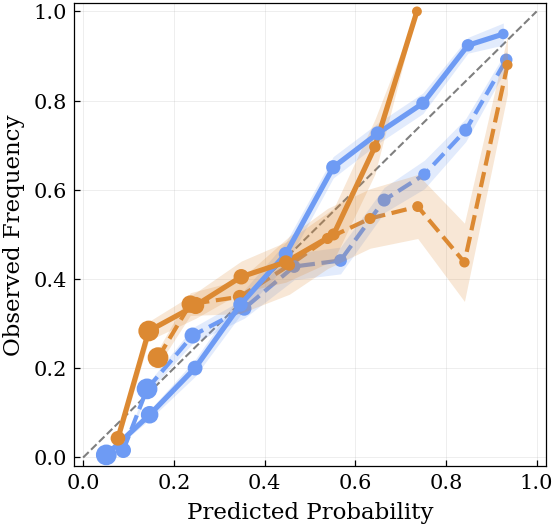

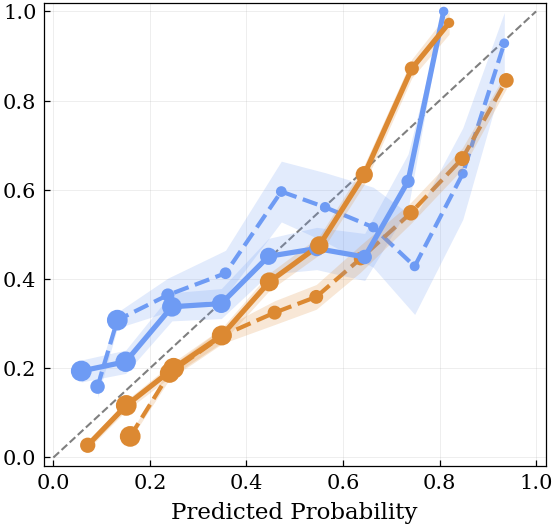

In [32]:
# Plot Calibration:
plot_calibration_curves(setting_results, dtype='syn')

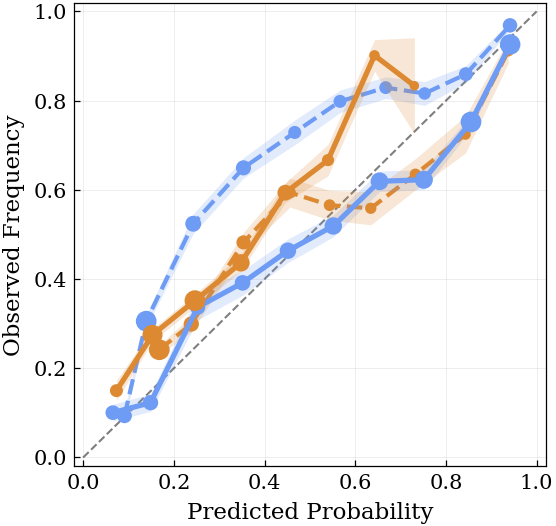

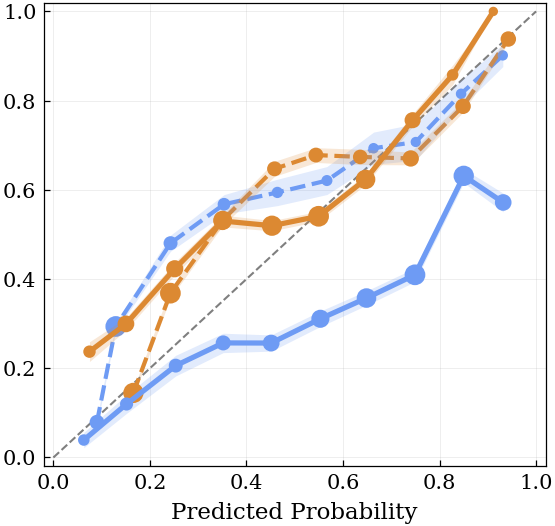

In [33]:
plot_calibration_curves(setting_results, dtype='real')

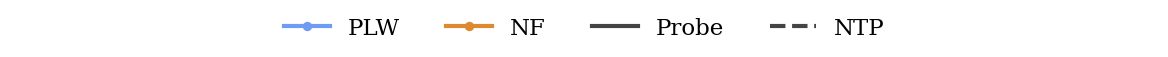

In [35]:
# ── Standalone calibration legend ─────────────────────────────────────────────
_legend_handles = [
        mlines.Line2D([], [], color=palette[7], lw=2, marker='o', ms=3.5, label='PLW'),
        mlines.Line2D([], [], color=palette[1], lw=2, marker='o', ms=3.5, label='NF'),
        mlines.Line2D([], [], color='#444444', lw=2, linestyle='-',  label='Probe'),
        mlines.Line2D([], [], color='#444444', lw=2, linestyle='--', label='NTP'),
    ]
_fig_leg, _ax_leg = plt.subplots(figsize=(10.0, 0.45))
_ax_leg.axis('off')
_ax_leg.legend(handles=_legend_handles, loc='center', ncol=6, fontsize=11,
            frameon=False, handlelength=2.0)
_fig_leg.savefig(FIGURES_DIR / 'legend_calibration.pdf', bbox_inches='tight', dpi=200)
plt.show()

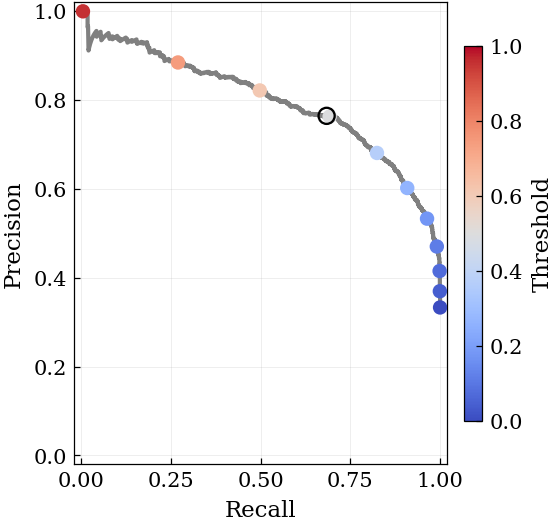

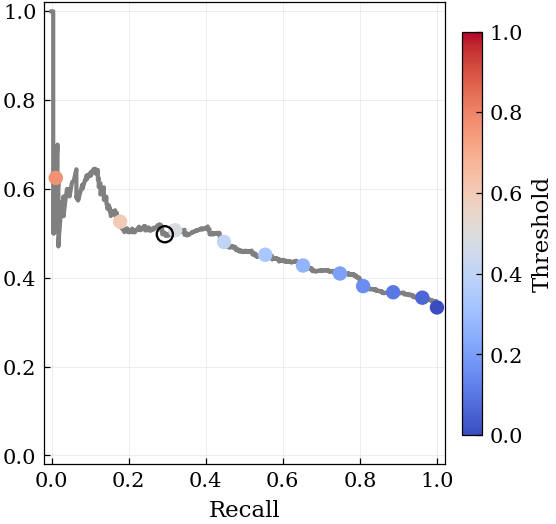

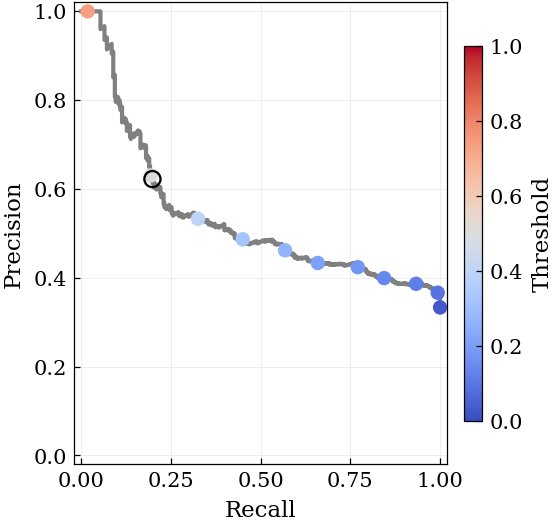

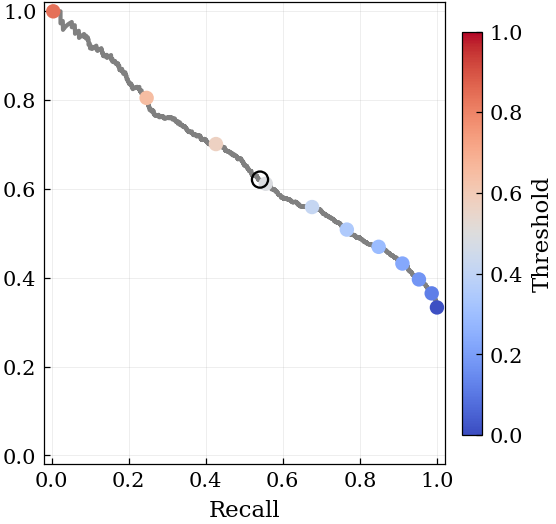

In [44]:
plot_pr_curves(setting_results, dtype='syn')

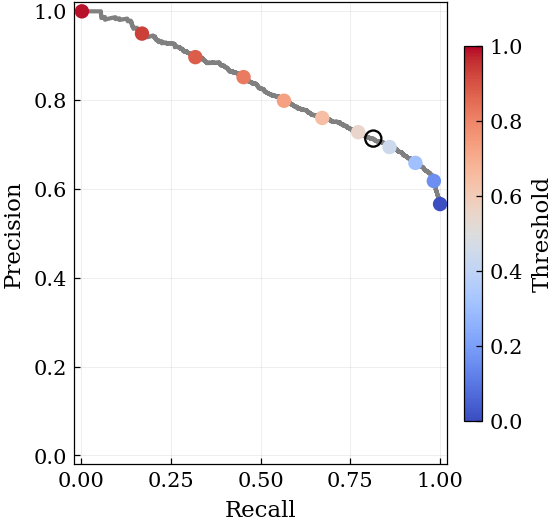

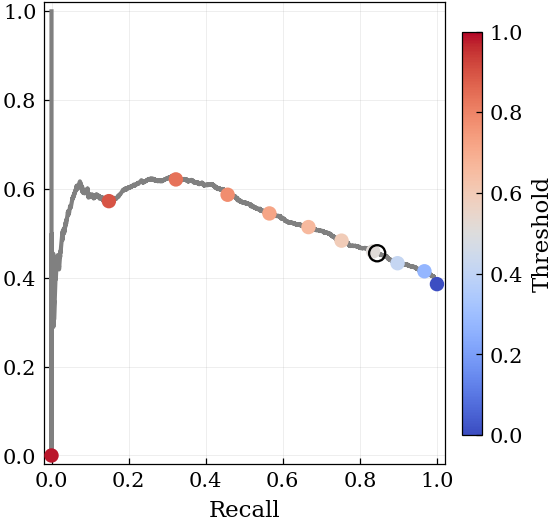

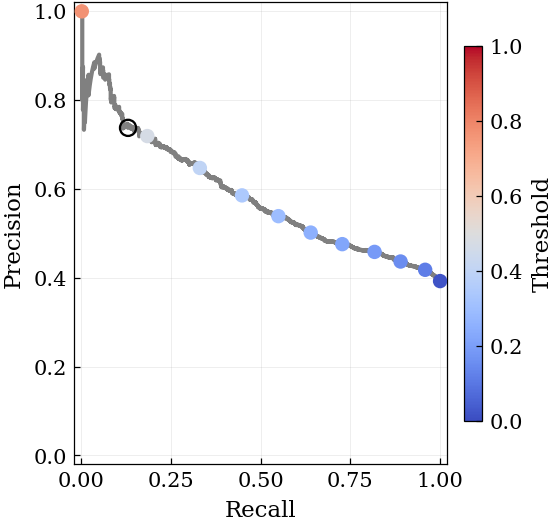

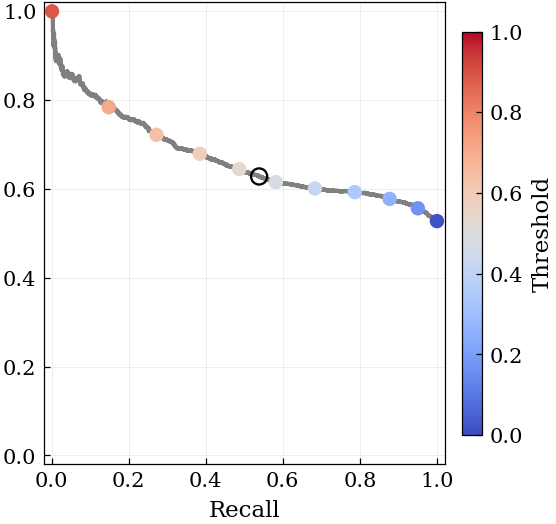

In [45]:
plot_pr_curves(setting_results, dtype='real')

In [46]:
metrics_df = compute_metrics(setting_results)
print(metrics_df.to_string(index=False, float_format='{:.3f}'.format))
metrics_df.to_csv(RESULTS_DIR / f'metrics_{EXTRACTION_MODEL}_{PROBE_TYPE}.csv', index=False)

Dataset type  Judge model Train dataset Test dataset  Type  Accuracy  Precision  Recall    F1  AUROC   ECE
         syn llama-3.1-8b          pond         pond   NTP     0.755      0.651   0.570 0.608  0.810 0.049
         syn llama-3.1-8b          pond         pond Probe     0.824      0.765   0.684 0.722  0.897 0.048
         syn llama-3.1-8b          pond         nfix   NTP     0.682      0.581   0.167 0.260  0.656 0.136
         syn llama-3.1-8b          pond         nfix Probe     0.667      0.500   0.294 0.370  0.650 0.079
         syn llama-3.1-8b          nfix         pond   NTP     0.737      0.591   0.682 0.633  0.810 0.118
         syn llama-3.1-8b          nfix         pond Probe     0.737      0.621   0.540 0.578  0.780 0.055
         syn llama-3.1-8b          nfix         nfix   NTP     0.684      0.556   0.267 0.361  0.656 0.078
         syn llama-3.1-8b          nfix         nfix Probe     0.693      0.622   0.198 0.301  0.682 0.086
        real llama-3.1-8b          po